# Backtest and Analysis Notebook

In [39]:
import pandas as pd
import numpy as np
import yfinance as yf
import math
from scipy.stats import norm
from datetime import date
import matplotlib.pyplot as plt
from tqdm import tqdm

# — Data Loader Functions —
def load_minute_underlying(symbol: str, start: str, end: str, interval: str='1m') -> pd.DataFrame:
    df = yf.Ticker(symbol).history(start=start, end=end, interval=interval)
    df = df.reset_index()[['Datetime','Close']]
    df.columns = ['datetime','underlying_price']
    # strip timezone for compatibility
    df['datetime'] = df['datetime'].dt.tz_localize(None)
    return df

def fetch_daily_options(symbol: str) -> pd.DataFrame:
    tk = yf.Ticker(symbol)
    today = date.today()
    underlying_price = tk.history(period="1d")["Close"].iloc[-1]
    all_opts = []
    for exp in tk.options:
        expiry = pd.to_datetime(exp).date()
        chain = tk.option_chain(exp)
        for side, typ in [(chain.calls, "call"), (chain.puts, "put")]:
            df = side.copy()
            df['option_type'] = typ
            df['expiry'] = pd.to_datetime(expiry).tz_localize(None)
            df['date'] = today
            df['underlying_price'] = underlying_price
            df['mid'] = (df['bid'] + df['ask']) / 2
            df = df[[
                'date','underlying_price','contractSymbol',
                'option_type','strike','expiry','bid','ask','mid'
            ]].rename(columns={'contractSymbol':'option_symbol'})
            all_opts.append(df)
    return pd.concat(all_opts, ignore_index=True)

# — Black-Scholes Pricing (vectorized) —
def black_scholes_vectorized(S, K, T, r, sigma, option_type):
    """
    Vectorized Black-Scholes price: arrays S, K, T, r, sigma
    option_type: array of 'call'/'put'
    """
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    call = S * norm.cdf(d1) - K * np.exp(-r*T) * norm.cdf(d2)
    put  = K * np.exp(-r*T) * norm.cdf(-d2) - S * norm.cdf(-d1)
    return np.where(option_type=='call', call, put)

# — Implied Volatility (only for signal rows) —
def implied_volatility(S, K, T, r, option_price, option_type, tol=1e-5, max_iter=100):
    sigma = math.sqrt(2*abs(math.log((S*math.exp(r*T))/K))/T)
    for _ in range(max_iter):
        price = black_scholes_vectorized(np.array([S]), np.array([K]), np.array([T]), r, np.array([sigma]), np.array([option_type]))[0]
        d1 = (math.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma * math.sqrt(T))
        vega = S * norm.pdf(d1) * math.sqrt(T)
        diff = price - option_price
        if abs(diff) < tol:
            return sigma
        sigma -= diff/vega
    return sigma  # fallback

# — Strategy & Trade Generation (Rolling Horizon) —
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

# Greek formulas: vectorized delta

def option_delta_vectorized(S, K, T, r, sigma, option_type):
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma * np.sqrt(T))
    call_delta = norm.cdf(d1)
    put_delta  = call_delta - 1
    return np.where(option_type=='call', call_delta, put_delta)

# Rolling-horizon trade generator

def generate_trades(df: pd.DataFrame, r: float=0.0,
                    edge_threshold: float=0.0,
                    max_contracts: int=1) -> pd.DataFrame:
    df = df.copy()
    df['datetime'] = pd.to_datetime(df['datetime'])
    # time to expiry
    df['T'] = (df['expiry'] - df['datetime']).dt.total_seconds()/(365*24*3600)
    df = df[df['T']>0]

    # historical vol (EWMA)
    u = df[['datetime','underlying_price']].drop_duplicates().set_index('datetime')
    ret = np.log(u['underlying_price']).diff().dropna()
    # EWMA window alpha=0.94 per minute
    ewma_var = ret.ewm(alpha=1-0.94).var()
    hist_sigma = np.sqrt(ewma_var) * np.sqrt(252*6.5*60)
    df = df.merge(hist_sigma.rename('sigma'), left_on='datetime', right_index=True, how='left')
    df['sigma'].fillna(method='ffill', inplace=True)
    df['sigma'].fillna(df['sigma'].mean(), inplace=True)

    # theoretical price & delta
    df['bs_price'] = black_scholes_vectorized(
        df['underlying_price'].values, df['strike'].values,
        df['T'].values, r, df['sigma'].values, df['option_type'].values
    )
    df['delta'] = option_delta_vectorized(
        df['underlying_price'].values, df['strike'].values,
        df['T'].values, r, df['sigma'].values, df['option_type'].values
    )

    # compute edge and raw signal
    df['edge'] = (df['bs_price'] - df['mid']).abs()
    df['raw_signal'] = 0
    df.loc[df['bs_price'] - df['mid'] > edge_threshold, 'raw_signal'] = 1
    df.loc[df['mid'] - df['bs_price'] > edge_threshold, 'raw_signal'] = -1

    # rolling-horizon: build trades
    trades = []
    open_pos = {}  # symbol -> (entry_idx, side, entry_price)
    for idx, row in df.iterrows():
        sym = row['option_symbol']
        sig = row['raw_signal']
        price = row['ask'] if sig==1 else (row['bid'] if sig==-1 else None)
        # entry
        if sym not in open_pos and sig!=0:
            # apply delta cap per trade
            if abs(row['delta'] * 100) > max_contracts:
                continue
            open_pos[sym] = (idx, sig, price)
        # exit
        elif sym in open_pos:
            ent_idx, ent_sig, ent_price = open_pos[sym]
            # exit if signal flips or zero
            if sig==0 or sig!=ent_sig:
                exit_price = row['bid'] if ent_sig==1 else row['ask']
                trades.append({
                    'entry_time': df.at[ent_idx,'datetime'],
                    'exit_time': row['datetime'],
                    'option_symbol': sym,
                    'size': ent_sig * 1,
                    'entry_price': ent_price,
                    'exit_price': exit_price,
                    'pnl': (exit_price - ent_price)*ent_sig*100
                })
                del open_pos[sym]
    trades_df = pd.DataFrame(trades)
    return trades_df

# — Analytics (PnL) —
def compute_pnl(trades_df: pd.DataFrame) -> pd.DataFrame:
    # aggregate by exit_date
    trades_df['exit_date'] = trades_df['exit_time'].dt.date
    daily = trades_df.groupby('exit_date')['pnl'].sum().reset_index()
    daily.columns = ['datetime','daily_pnl']
    daily['datetime'] = pd.to_datetime(daily['datetime'])
    daily['cumulative_pnl'] = daily['daily_pnl'].cumsum()
    return daily

In [40]:
symbol = 'SPY'
start, end = '2025-07-01', '2025-07-02'
r = 0.01
# New parameters
months_to_include = 2       # number of front expiries to include (e.g. front + next month)
edge_threshold = 0.5        # minimum model-mid difference to trigger a trade
max_contracts = 5           # maximum contracts per symbol

In [41]:
# Load minute-level underlying (tz-stripped)
u_df = load_minute_underlying(symbol, start, end)
u_df.to_csv('data/minute_underlying.csv', index=False)

# Fetch full option chain and include first N expiries for mispricing
full_chain = fetch_daily_options(symbol)
eps = sorted(full_chain['expiry'].unique())[:months_to_include]
o_chain = full_chain[full_chain['expiry'].isin(eps)].copy()
o_chain.to_csv('data/option_chain.csv', index=False)

In [42]:
# Merge minute bars with selected strikes
tc = o_chain.drop(columns=['underlying_price']).copy()
tu = u_df.copy()
tu['key'] = 1
tc['key'] = 1
minute_df = tu.merge(tc, on='key').drop('key', axis=1)

# === DEBUGGING: inspect the merged DataFrame ===
print("Merged columns:", minute_df.columns.tolist())
print(minute_df.head(3))

# Rename & drop columns if they exist
if 'underlying_price_x' in minute_df.columns:
    minute_df = minute_df.rename(columns={'underlying_price_x': 'underlying_price'})
# Safely drop
minute_df = minute_df.drop(columns=['underlying_price_y'], errors='ignore')

# Save
minute_df.to_csv('data/minute_simulated_chain.csv', index=False)

Merged columns: ['datetime', 'underlying_price', 'date', 'option_symbol', 'option_type', 'strike', 'expiry', 'bid', 'ask', 'mid']
             datetime  underlying_price        date       option_symbol  \
0 2025-07-01 09:30:00        616.599976  2025-07-19  SPY250721C00570000   
1 2025-07-01 09:30:00        616.599976  2025-07-19  SPY250721C00575000   
2 2025-07-01 09:30:00        616.599976  2025-07-19  SPY250721C00580000   

  option_type  strike     expiry    bid    ask     mid  
0        call   570.0 2025-07-21  56.55  58.66  57.605  
1        call   575.0 2025-07-21  51.55  53.66  52.605  
2        call   580.0 2025-07-21  46.56  48.67  47.615  


In [43]:
trades_df = generate_trades(
    minute_df,
    r=r,
    edge_threshold=edge_threshold,
    max_contracts=max_contracts
)
trades_df.to_csv('data/trades.csv', index=False)

pnl_df = compute_pnl(trades_df)
pnl_df.to_csv('data/pnl.csv', index=False)

C:\Users\44750\AppData\Local\Temp\ipykernel_11964\1794348170.py:96: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['sigma'].fillna(method='ffill', inplace=True)


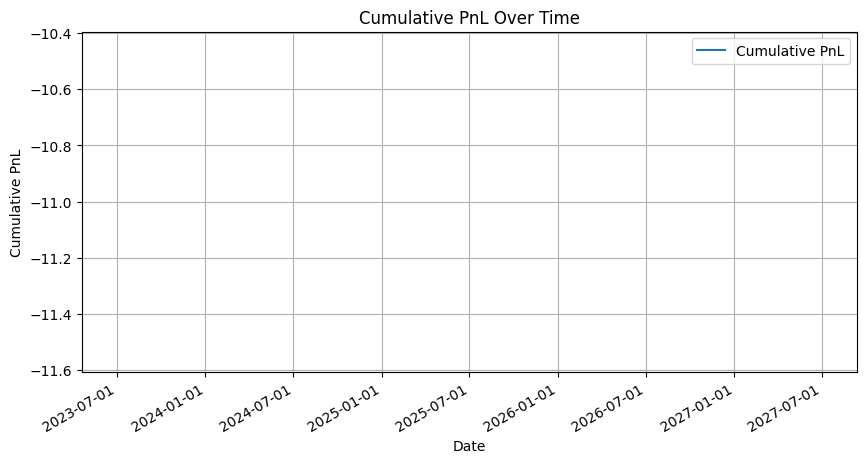

In [44]:
import matplotlib.dates as mdates
plt.figure(figsize=(10,5))
plt.plot(pnl_df['datetime'], pnl_df['cumulative_pnl'], label='Cumulative PnL')
ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gcf().autofmt_xdate()
plt.xlabel('Date')
plt.ylabel('Cumulative PnL')
plt.title('Cumulative PnL Over Time')
plt.grid(True)
plt.legend()
plt.show()